# CI failure classification

**Recipe 19** · Level 2 (Easy) · Decision type: `Choice`

Classify a trimmed excerpt of a continuous-integration log as a test regression, a dependency problem, an infrastructure failure, or unknown, and use that to pick the next diagnostic workflow.

Sources:

- S02: [TypeSafe AI: Primitives (Questions)](https://docs.typesafe.ai/primitives)
- S03: [TypeSafe AI: Confidence](https://docs.typesafe.ai/confidence)
- S04: [TypeSafe AI: How to build with TypeSafe](https://docs.typesafe.ai/concepts/how-to-build-with-system-one)
- S05: [TypeSafe AI: Example use cases](https://docs.typesafe.ai/concepts/use-case-map)

## What you will build

A classifier for CI failure logs. Python trims each build's log down to the excerpt that matters *before* it ever builds a request, keeping the untrimmed log in the fixtures so the trimming below is checked against real data, not merely illustrated. Jev then reads the excerpt and picks exactly one of four outcomes: `test_regression`, `dependency_problem`, `infrastructure_failure`, or `unknown`. Every one of the four goes through the same confidence gate: below it, a build is sent to a review queue for a person to decide; at or above it, Python looks up the next diagnostic workflow from a fixed table. Three of those four workflows name an automated remedy a real system would act on, so Python logs them to a simulated action log; the fourth, `unknown`'s own workflow (manual triage), names no automated remedy at all, so an accepted `unknown` answer is logged to the same review queue instead -- accepted, not rejected for low confidence, but still a person's decision either way. By the end you will have looked at individual typed answers across the hard cases this use case names, including one where the trimming itself decides what Jev can see, and run an evaluation that chooses its one setting on `validation` and reports on `test`.

## Setup and run mode

The notebook runs from its own folder with the standard library and `jev_cookbook` only. `get_backend(fixtures=...)` replays the 40 stored answers in `fixtures/responses.json` offline; setting `JEV_COOKBOOK_LIVE=1` (see the README) swaps in live calls to the same question definitions and changes nothing else. `run_header` states which mode ran, and every number below carries that mode with it.

In [1]:
from collections import Counter

from jev_cookbook import get_backend, load_helpers
from jev_cookbook.evaluation import (
    accuracy,
    confusion_matrix,
    evaluate_outcomes,
    per_class_metrics,
    select_confidence_threshold,
    selective_curve,
)
from jev_cookbook.fixtures import load_inputs, load_labels, responses_path, select_split
from jev_cookbook.simulation import ActionLog, ReviewQueue
from jev_cookbook.style import (
    apply_style,
    plot_answer_probabilities,
    plot_confusion_matrix,
    plot_risk_coverage,
    run_header,
    show_answer,
)

apply_style()
helpers = load_helpers()  # this recipe's helpers.py, loaded by path
examples = load_inputs()
labels = load_labels()
backend = get_backend(fixtures=responses_path())
questions = helpers.build_questions()
# N for the header is the number of examples the metrics are about: validation and test. This
# recipe has no train split; demo examples are shown but never scored.
scored = [e for e in examples if e.split not in ("train", "demo")]

offline = backend.mode in ("synthetic", "scripted")
check = " (a pipeline check, not a Jev result)" if offline else ""
# CONTRIBUTING.md section 2: "a number from the validation split is a selection step, not a
# result." This label does not depend on the run mode, unlike `check` above.
selection = " (a selection step, not a reported result)"

# Every one of the 40 examples in fixtures/ needs at most one request. This cache makes sure a
# build that is shown individually and later scored in its split is decided once, so the whole
# notebook makes exactly 40 requests in live mode, never more.
answered = {}


def decide(example):
    if example.id not in answered:
        answered[example.id] = backend.decide(helpers.build_state(example.fields), questions)[
            "outcome"
        ]
    return answered[example.id]


run_header(19, "CI failure classification", backend=backend, n_examples=len(scored))

Recipe 19: CI failure classification
Mode: offline replay of synthetic fixtures, pipeline check on a fixture sample of 38 examples
Metrics in this run are checks that the pipeline works. They are not Jev results.


## The state

Python trims each build's log down to the excerpt it actually sends to Jev, *before* it builds a request: `helpers.trim_log` keeps a one-line window around every line that names a dependency or infrastructure problem, wherever it falls in the log, plus a window around the first line that names a test failure. The untrimmed log stays in `fixtures/inputs.jsonl` next to the trimmed state, so the trimming below is the trimming the request is actually built from, not a separate illustration of it.

In [2]:
examples_by_id = {e.id: e for e in examples}
demo = {e.id: e for e in examples if e.split == "demo"}
fartrim = examples_by_id["v-dep-04-fartrim"]
print(f"full log: {len(fartrim.fields['full_log'].splitlines())} lines")
print(fartrim.fields["full_log"])

full log: 39 lines
$ pytest -q
============================= test session starts ==============================
collected 212 items
tests/ .......F......................................

=================================== FAILURES ====================================
____________________________ tests/test_timezone_utils.py::test_dst_rounding ____________________________
    assert total == 3.14
E   AssertionError: assert 3.15 == 3.14
FAILED tests/test_timezone_utils.py::test_dst_rounding - AssertionError: assert 3.15 == 3.14
tests/test_module_00.py ........................... [ 40%]
tests/test_module_01.py ........................... [ 41%]
tests/test_module_02.py ........................... [ 42%]
tests/test_module_03.py ........................... [ 43%]
tests/test_module_04.py ........................... [ 44%]
tests/test_module_05.py ........................... [ 45%]
tests/test_module_06.py ........................... [ 46%]
tests/test_module_07.py ........................... [ 

The decisive line, a `ModuleNotFoundError` for `geo_sdk.regions`, sits more than twenty lines past the first failure this log shows, an unrelated assertion in `tests/test_timezone_utils.py::test_dst_rounding`. A trimming rule that only kept a window around the first failure would never see it. `trim_log` instead keeps every line naming a dependency or infrastructure problem wherever it falls, plus a window around the first test failure, so both survive.

In [3]:
excerpt = helpers.build_state(fartrim.fields)["log_excerpt"]
print(f"excerpt: {len(excerpt.splitlines())} lines")
print(excerpt)

excerpt: 8 lines
    assert total == 3.14
E   AssertionError: assert 3.15 == 3.14
FAILED tests/test_timezone_utils.py::test_dst_rounding - AssertionError: assert 3.15 == 3.14
...
    import geo_sdk
E   ModuleNotFoundError: No module named 'geo_sdk.regions'
FAILED tests/test_region_lookup.py::test_resolve_region_code - ModuleNotFoundError: No module named 'geo_sdk.regions'
2 failed, 210 passed in 58.21s


This excerpt, not the full log above, is what Jev actually sees for this build: the decisive `ModuleNotFoundError` is on screen even though it was buried past two dozen lines of unrelated passing tests. The gap between the two kept windows is marked `...`.

## The questions

There is one question, and it asks one thing: given the excerpt, which outcome best explains why the build failed? A `Choice` fits because the four outcomes are exclusive and Jev should commit to exactly one. The option set is fixed to the four outcomes the use case names, built by Python in `helpers.OUTCOMES`: there is no free-text category Jev could invent, only this list with its description, which is the candidate set this recipe assembles and shows the reader.

A `Choice` answer's `confidence` is the top probability rescaled by the number of options, `(p_max - 1/n) / (1 - 1/n)`: 0 when the top outcome has no more than an even quarter-share of the four, 1 when one outcome holds all the probability. A low confidence here does not mean a log is unreadable; it means the top outcome did not pull far ahead of an even split across the four.

In [4]:
outcome_question = questions["outcome"]
print(outcome_question.instructions)
for name, description in outcome_question.criteria.items():
    print(f"  {name:24s} {description}")

This is an excerpt from a continuous-integration log. Which outcome best explains why the build failed?
  test_regression          A real behaviour change in the code under test broke a test that used to pass: the failure is a genuine assertion about the code's output, not about the environment the code ran in.
  dependency_problem       A package could not be installed, imported, or resolved to a compatible version. This also covers a failing test whose traceback ends in an import or module error: the test did not find a real behaviour change, it could not even load the package under test. When an excerpt shows both an import or module error and an unrelated assertion failure elsewhere, the import or module error governs: nothing the other test asserted can be trusted once a dependency the run needs is missing.
  infrastructure_failure   The build or test runner itself failed, independent of the code under test: it lost its connection, ran out of memory or disk, or was killed or shut 

## One answer up close

Before any aggregate number, look at four typed answers that cover what this recipe is built to show: a dependency problem that surfaces as a failing test, the trimming example above with its far-away decisive line, a flaky and genuinely ambiguous log, and a confident, unambiguous case for contrast. Each answer holds the chosen outcome, a probability for every outcome, the `confidence` explained above, and a `provenance` line, here always `synthetic`, since nothing in this recipe's fixtures came from a real call.

$ pytest -q
============================= test session starts ==============================
collected 128 items
tests/ ..............F.........

=================================== FAILURES ====================================
____________________________ tests/test_ticket_sync.py::test_sync_marks_resolved ____________________________
    import support_sdk
E   ModuleNotFoundError: No module named 'support_sdk.v3'
FAILED tests/test_ticket_sync.py::test_sync_marks_resolved - ModuleNotFoundError: No module named 'support_sdk.v3'
1 failed, 127 passed in 19.02s
Choice: test_regression (confidence 0.67)
  test_regression         0.75  ###############
  dependency_problem      0.08  ##
  infrastructure_failure  0.08  ##
  unknown                 0.08  ##
Provenance: synthetic


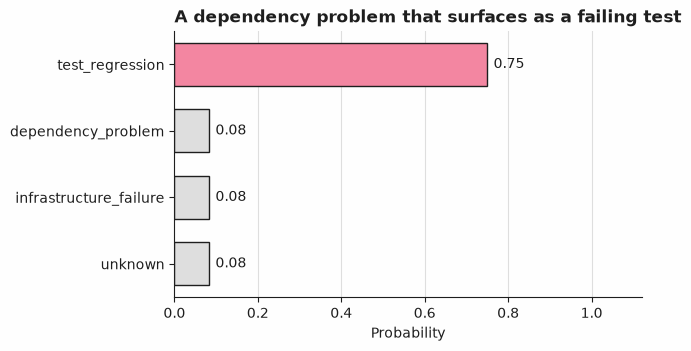

In [5]:
surfaces_example = demo["demo-01-dep-surfaces"]
surfaces_answer = decide(surfaces_example)
print(surfaces_example.fields["full_log"])
show_answer(surfaces_answer)
plot_answer_probabilities(
    surfaces_answer, title="A dependency problem that surfaces as a failing test"
)

The failing test's traceback ends in `ModuleNotFoundError: No module named 'support_sdk.v3'`: the real cause is a dependency this fabricated build's own code never resolved, not a change in behaviour. The stored answer calls it `test_regression` anyway, at confidence 0.67. This demo build carries no **gold label** -- the correct outcome, written into the fixtures by whoever built them, never by Jev, used only to score an answer after the fact -- because demo examples are never scored; the identical pattern recurs, scored, in `validation` and `test` below, including a confidently wrong case in each.

In [6]:
fartrim_answer = decide(fartrim)
show_answer(fartrim_answer)

Choice: dependency_problem (confidence 0.44)
  dependency_problem      0.58  ############
  test_regression         0.14  ###
  infrastructure_failure  0.14  ###
  unknown                 0.14  ###
Provenance: synthetic


This is the same `v-dep-04-fartrim` build from "The state" above. The stored answer correctly calls it `dependency_problem`, but at a lower confidence (0.44) than the surfaces example above (0.67): this fixture's probabilities were written with more weight left on the other three outcomes, to model a build whose excerpt carries two decisive-looking windows rather than one clean signal -- the description above says which one governs when both appear. The number comes from the fixtures, not a measurement of anything.

In [7]:
flaky_example = demo["demo-02-unknown-flaky"]
flaky_answer = decide(flaky_example)
print(flaky_example.fields["full_log"])
show_answer(flaky_answer)

$ pytest -q
============================= test session starts ==============================
collected 140 items
tests/ ................................

=================================== FAILURES ====================================
____________________________ tests/test_notification_batch.py::test_batch_dedup ____________________________
E   AssertionError: assert False == True
FAILED tests/test_notification_batch.py::test_batch_dedup - AssertionError (flaky: passed on rerun 1/1)
139 passed, 1 flaky test rerun and passed in 33.04s
Choice: unknown (confidence 0.53)
  unknown                 0.65  #############
  test_regression         0.12  ##
  dependency_problem      0.12  ##
  infrastructure_failure  0.12  ##
Provenance: synthetic


The test failed once and passed on an automatic rerun, with nothing else in the log pointing at a cause. The stored answer calls this `unknown` at confidence 0.53. `classify` below gates `unknown` exactly like every other outcome: a confident `unknown` answer is accepted, same as a confident `test_regression` answer, but because its workflow (`manual_triage`) names no automated remedy, it is logged to the review queue rather than the action log -- accepted, not rejected for low confidence, but still a person's decision to make.

In [8]:
contrast_example = examples_by_id["v-tr-01"]
contrast_answer = decide(contrast_example)
show_answer(contrast_answer)

Choice: test_regression (confidence 0.80)
  test_regression         0.85  #################
  dependency_problem      0.05  #
  infrastructure_failure  0.05  #
  unknown                 0.05  #
Provenance: synthetic


A clean, confident case for contrast: a genuine assertion failure, nothing ambiguous about it, at confidence 0.80. Whether that clears the bar below depends on the threshold "Python's part" chooses next.

## Python's part

Jev supplies the judgment; what happens with it is code. Every outcome goes through the same confidence gate first: an answer below the threshold is sent to a `ReviewQueue` with the reason `"confidence below the threshold"`, whatever it is. An answer at or above the threshold is accepted, and `helpers.WORKFLOWS` -- the fixed table the build notes ask for -- names what Python does with it: `test_regression` to `rerun_suite_with_bisect`, `dependency_problem` to `pin_and_rebuild_dependencies`, `infrastructure_failure` to `requeue_on_fresh_runner`, each logged to a simulated `ActionLog`, which never executes anything; `unknown` to `manual_triage`, which names no automated remedy, so it is logged to the *same* `ReviewQueue` instead, with the reason `"no option fits"`. Accepting `unknown` is not the same as rejecting it for low confidence: both land in the queue, but only one of them also clears the gate. `tests/test_helpers.py` checks this at the boundary, for every one of the four outcomes alike, and confirms that `unknown` lands in the queue rather than the log when accepted.

The threshold itself is chosen here, on `validation`, and then frozen for the rest of this notebook: `select_confidence_threshold` picks the lowest threshold whose answered subset is perfectly accurate on the 19 `validation` builds. Applying that frozen threshold to the four answers shown above produces three different workflows: two automated remedies logged to the action log (`rerun_suite_with_bisect`, picked twice; `pin_and_rebuild_dependencies`, once), and one, `manual_triage`, accepted the same way but logged to the review queue instead, because it names no automated remedy. What the gate does with an answer it is *not* confident enough to accept, whatever outcome that answer names, shows up on the fuller `validation` and `test` breakdowns below.

In [9]:
val_examples = select_split(examples, "validation")
val_answers = [decide(e) for e in val_examples]
val_gold = [labels[e.id] for e in val_examples]
val_correct = [a.choice == g for a, g in zip(val_answers, val_gold, strict=True)]
val_confidence = [a.confidence for a in val_answers]
threshold = select_confidence_threshold(val_correct, val_confidence, target_accuracy=1.0)
print(f"chosen threshold, frozen from here on: {threshold:.4f}{selection}{check}")

demo_actions, demo_queue = ActionLog(), ReviewQueue()
for shown_id, shown_example, shown_answer in (
    ("demo-01-dep-surfaces", surfaces_example, surfaces_answer),
    ("v-dep-04-fartrim", fartrim, fartrim_answer),
    ("demo-02-unknown-flaky", flaky_example, flaky_answer),
    ("v-tr-01", contrast_example, contrast_answer),
):
    diagnosis = helpers.classify(
        shown_example.fields["build_id"],
        shown_answer,
        threshold,
        actions=demo_actions,
        queue=demo_queue,
    )
    workflow = f" ({diagnosis.workflow})" if diagnosis.workflow else ""
    print(
        f"{shown_id}: {shown_answer.choice} at confidence {shown_answer.confidence:.2f} "
        f"-> {diagnosis.outcome}{workflow} [{diagnosis.reason}]"
    )

chosen threshold, frozen from here on: 0.4400 (a selection step, not a reported result) (a pipeline check, not a Jev result)
demo-01-dep-surfaces: test_regression at confidence 0.67 -> test_regression (rerun_suite_with_bisect) [confident match]
v-dep-04-fartrim: dependency_problem at confidence 0.44 -> dependency_problem (pin_and_rebuild_dependencies) [confident match]
demo-02-unknown-flaky: unknown at confidence 0.53 -> unknown (manual_triage) [no option fits]
v-tr-01: test_regression at confidence 0.80 -> test_regression (rerun_suite_with_bisect) [confident match]


## Evaluation

The threshold was chosen and frozen above, on `validation`. Every outcome goes through the same gate: whether `classify` accepts an answer at all is exactly `confidence >= threshold`, nothing else. An accepted answer is not automatically a build this evaluation counts as *answered*, though: `classify` reports `unknown` as a deferral, not a cause -- naming it is itself asking a person to find the real one -- so CONTRIBUTING.md section 4 part (a) counts it toward review, never toward coverage, however confidently Jev named it. `helpers.accepted_and_correct` builds the two arrays [`jev_cookbook.evaluation.evaluate_outcomes`](../../docs/evaluation.md) needs for exactly that split: **coverage** is the fraction of builds `classify` reports with one of the three substantive outcomes, and among those, **accuracy** is the fraction right and **risk** is its complement, `1 - accuracy`. Alongside that, `jev_cookbook.evaluation` reports accuracy of the raw choice and a confusion matrix against the gold labels over all four outcomes. In an offline run every `test` number here is a check that the pipeline works, and it says so; every `validation` number, in every run mode, is a selection step *and* a pipeline check, which is why it carries both labels.

In [10]:
def logged_workflows(actions, queue):
    """Every workflow accepted for a split: the three substantive ones from actions, plus
    unknown's from queue items accepted rather than rejected for low confidence."""
    fired = set(Counter(e["kind"] for e in actions.to_dicts()))
    fired |= {i["item"]["workflow"] for i in queue.to_dicts() if i["reason"] == "no option fits"}
    return fired


def show_log(name, actions, queue):
    print(f"{name} action log: {len(actions)} entries{check}")
    for kind, n in sorted(Counter(e["kind"] for e in actions.to_dicts()).items()):
        executed = {e["executed"] for e in actions.by_kind(kind)}
        print(f"  {kind:28s} {n}  executed={executed}")
    print(f"{name} review queue: {len(queue)} entries{check}")
    for reason, n in sorted(Counter(i["reason"] for i in queue.to_dicts()).items()):
        print(f"  {reason:32s} {n}")


val_actions, val_queue = ActionLog(), ReviewQueue()
val_diagnoses = [
    helpers.classify(e.fields["build_id"], a, threshold, actions=val_actions, queue=val_queue)
    for e, a in zip(val_examples, val_answers, strict=True)
]
val_gold_by_build = {e.fields["build_id"]: g for e, g in zip(val_examples, val_gold, strict=True)}
val_accepted, val_correct2 = helpers.accepted_and_correct(val_diagnoses, val_gold_by_build)
val_outcomes = evaluate_outcomes(val_accepted, val_correct2)

print(f"validation, {len(val_examples)} examples{selection}{check}")
print(f"accuracy of the raw choice: {accuracy(val_gold, val_answers):.4f}{selection}{check}")
print(
    f"answered (coverage): {val_outcomes.n_answered} of {val_outcomes.n_total} "
    f"(coverage {val_outcomes.coverage:.4f}){selection}{check}"
)
print(f"accuracy among those answered: {val_outcomes.accuracy:.4f}{selection}{check}")
print(f"risk among those answered: {val_outcomes.risk:.4f}{selection}{check}")
show_log("validation", val_actions, val_queue)
print(
    f"workflow rows fired on validation: {sorted(logged_workflows(val_actions, val_queue))}{selection}{check}"
)

validation, 19 examples (a selection step, not a reported result) (a pipeline check, not a Jev result)
accuracy of the raw choice: 0.8947 (a selection step, not a reported result) (a pipeline check, not a Jev result)
answered by the gate: 14 of 19 (coverage 0.7368) (a selection step, not a reported result) (a pipeline check, not a Jev result)
accuracy among those answered: 1.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
risk among those answered: 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
validation action log: 12 entries (a pipeline check, not a Jev result)
  pin_and_rebuild_dependencies 4  executed={False}
  requeue_on_fresh_runner      4  executed={False}
  rerun_suite_with_bisect      4  executed={False}
validation review queue: 7 entries (a pipeline check, not a Jev result)
  confidence below the threshold   5
  no option fits                   2
workflow rows fired on validation: ['manual_triage', 'p

14 of the 19 validation builds clear the confidence gate, but only 12 of those count toward coverage: 12 get an automated remedy (4 of each of the three substantive workflows, logged to the action log with `executed=False`, since nothing here is ever really run), and the other 2 are confident `unknown` builds, accepted by the gate and queued for a person like every other `unknown` -- a deferral, so `helpers.accepted_and_correct` marks them `accepted=False` even though the gate let them through. `accuracy` and `risk` are over those 12, not all 14: both confident `unknown` builds happen to be right (their gold label is `unknown` too), so excluding them from coverage costs nothing here -- `risk` is still `0.0000`, by construction, not by luck: `select_confidence_threshold(target_accuracy=1.0)` chose the lowest threshold with perfect raw accuracy among the gate-accepted validation builds, so a wrong accepted answer here would mean the selector itself had failed.

test, 19 examples, threshold 0.4400 frozen (a pipeline check, not a Jev result)
accuracy of the raw choice: 0.8947 (a pipeline check, not a Jev result)
answered by the gate: 15 of 19 (coverage 0.7895) (a pipeline check, not a Jev result)
accuracy among those answered: 0.8667 (a pipeline check, not a Jev result)
risk among those answered: 0.1333 (a pipeline check, not a Jev result)
test action log: 12 entries (a pipeline check, not a Jev result)
  pin_and_rebuild_dependencies 3  executed={False}
  requeue_on_fresh_runner      4  executed={False}
  rerun_suite_with_bisect      5  executed={False}
test review queue: 7 entries (a pipeline check, not a Jev result)
  confidence below the threshold   4
  no option fits                   3
workflow rows fired on test: ['manual_triage', 'pin_and_rebuild_dependencies', 'requeue_on_fresh_runner', 'rerun_suite_with_bisect'] (a pipeline check, not a Jev result)
confusion matrix, gold (rows) by predicted (columns) (a pipeline check, not a Jev result

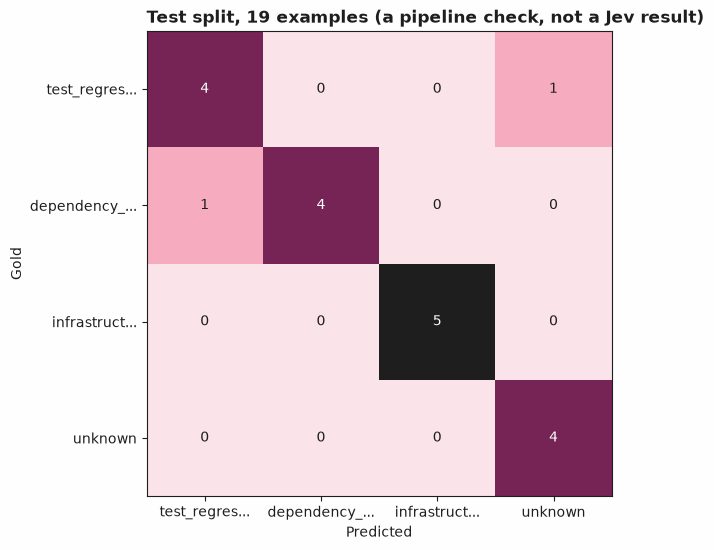

In [11]:
test_examples = select_split(examples, "test")
test_answers = [decide(e) for e in test_examples]
test_gold = [labels[e.id] for e in test_examples]
test_correct = [a.choice == g for a, g in zip(test_answers, test_gold, strict=True)]
test_confidence = [a.confidence for a in test_answers]

test_actions, test_queue = ActionLog(), ReviewQueue()
test_diagnoses = [
    helpers.classify(e.fields["build_id"], a, threshold, actions=test_actions, queue=test_queue)
    for e, a in zip(test_examples, test_answers, strict=True)
]
test_gold_by_build = {
    e.fields["build_id"]: g for e, g in zip(test_examples, test_gold, strict=True)
}
test_accepted, test_correct2 = helpers.accepted_and_correct(test_diagnoses, test_gold_by_build)
test_outcomes = evaluate_outcomes(test_accepted, test_correct2)

print(f"test, {len(test_examples)} examples, threshold {threshold:.4f} frozen{check}")
print(f"accuracy of the raw choice: {accuracy(test_gold, test_answers):.4f}{check}")
print(
    f"answered (coverage): {test_outcomes.n_answered} of {test_outcomes.n_total} "
    f"(coverage {test_outcomes.coverage:.4f}){check}"
)
print(f"accuracy among those answered: {test_outcomes.accuracy:.4f}{check}")
print(f"risk among those answered: {test_outcomes.risk:.4f}{check}")
show_log("test", test_actions, test_queue)
print(f"workflow rows fired on test: {sorted(logged_workflows(test_actions, test_queue))}{check}")

matrix = confusion_matrix(test_gold, test_answers, labels=list(helpers.OUTCOMES))
print(f"confusion matrix, gold (rows) by predicted (columns){check}")
header = "".join(f"{name:>26s}" for name in matrix.labels)
print(f"{'':24s}{header}")
for gold_name, row in zip(matrix.labels, matrix.matrix, strict=True):
    cells_text = "".join(f"{v:>26d}" for v in row)
    print(f"{gold_name:24s}{cells_text}")
plot_confusion_matrix(matrix, title=f"Test split, {len(test_examples)} examples{check}")

15 of the 19 test builds clear the confidence gate, but only 12 of those count toward coverage (0.6316): 12 automated remedies, logged across all three substantive workflows, and 3 confident `unknown` builds that the gate accepts but `helpers.accepted_and_correct` still marks `accepted=False`, because naming `unknown` is itself a deferral, not a cause, whatever its confidence -- the remaining 4 builds are rejected for low confidence and land in the same queue with a different reason. Of the 12 that count as answered, 1 is wrong: `t-dep-02-surfaces`, a dependency problem that surfaces as a failing test, confidently (0.6667, comfortably above the 0.4400 gate) called `test_regression` instead -- which is where `risk 0.0833` (1 of 12) comes from, the gate screening out *low-confidence* misreads (there are none left among the answered builds) rather than every misread that happens to be confident. The raw choice makes a second mistake on this split, but it never reaches this count: `t-tr-05-wrong` -- a build whose two failures are both genuine regressions from one shared change, but look unrelated at a glance -- is also named wrong by the raw choice (`unknown` instead of `test_regression`), yet because `unknown` is a deferral it is excluded from coverage's accuracy and risk regardless of confidence; it counts toward review instead, which is exactly where a wrong hedge is supposed to land. Its excerpt, shown next, carries both failures, not only the full log. Nothing else is misclassified; `infrastructure_failure` has no errors at all on this split, including its own hard case, the runner lost mid-test.

In [12]:
hedge_example = examples_by_id["t-tr-05-wrong"]
print(helpers.trim_log(hedge_example.fields["full_log"]))


tests/test_loyalty_points.py::test_points_awarded_per_purchase:42: AssertionError: assert 80 == 100
tests/test_cart_summary.py::test_grand_total_rounding:17: AssertionError: assert 49.49 == 49.99


Both failures survive the trim, not only the full log: `trim_log` anchors its one window on the first failure, and pytest's own `--tb=line` format (one line per failure, no separating header between them) keeps the second failure inside that same window. The hedge the stored answer makes has a basis in what this excerpt actually shows.

The chosen threshold is not the only one the gate could use. `selective_curve` sweeps every distinct confidence value observed on `validation` and reports coverage and risk at each; `plot_risk_coverage` draws it, so the trade-off the frozen threshold makes is visible, not only the one point it lands on.

threshold 0.8400  coverage 0.0526  accuracy 1.0000  risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
threshold 0.8133  coverage 0.1053  accuracy 1.0000  risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
threshold 0.8000  coverage 0.1579  accuracy 1.0000  risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
threshold 0.7733  coverage 0.2105  accuracy 1.0000  risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
threshold 0.7600  coverage 0.2632  accuracy 1.0000  risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
threshold 0.7333  coverage 0.3158  accuracy 1.0000  risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
threshold 0.6000  coverage 0.3684  accuracy 1.0000  risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)

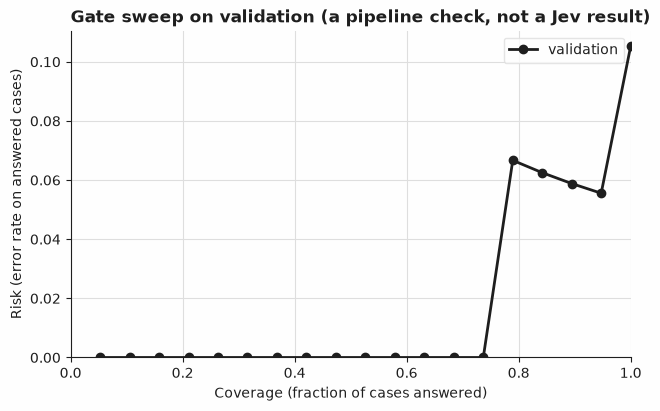

In [13]:
curve = selective_curve(val_correct, val_confidence)
for t, cov, acc, risk in zip(
    curve.thresholds, curve.coverage, curve.accuracy, curve.risk, strict=True
):
    chosen = "  <- frozen" if abs(t - threshold) < 1e-9 else ""
    print(
        f"threshold {t:.4f}  coverage {cov:.4f}  accuracy {acc:.4f}  risk {risk:.4f}{chosen}{selection}{check}"
    )
print(
    f"{len(curve.thresholds)} distinct validation confidence values swept above{selection}{check}"
)
plot_risk_coverage(curve, label="validation", title=f"Gate sweep on validation{check}")

`0.4400` is the lowest of fourteen distinct thresholds on this sweep with zero risk: every one of the thirteen higher than it costs coverage for no gain in accuracy, which is exactly why `select_confidence_threshold` picks the lowest one. The first threshold with any risk at all sits one step below, at `0.3600` (accuracy `0.9333`, one wrong validation answer let through); every threshold below that costs still more accuracy for still more coverage. The frozen gate is a real, working instrument on this fixture set, not a single arbitrary point on a short staircase: the sweep above prints every distinct threshold the curve has, and `0.4400` is where the risk-free band ends.

Two baselines without any typed answer at all, for scale. The first is as trivial as a baseline can be: predict whatever outcome is most common on `validation`, for every `test` build, regardless of its log. The second uses the same keyword patterns `trim_log` already scans for (`helpers.DEPENDENCY_RE`, `helpers.INFRASTRUCTURE_RE`, `helpers.FAILURE_RE`), checked in that order against the *untrimmed* log, with no judgment about how the signals interact and no excerpt at all.

In [14]:
majority_label, _ = Counter(val_gold).most_common(1)[0]
majority_accuracy = accuracy(test_gold, [majority_label] * len(test_gold))


def keyword_baseline(full_log):
    if helpers.DEPENDENCY_RE.search(full_log):
        return helpers.DEPENDENCY_PROBLEM
    if helpers.INFRASTRUCTURE_RE.search(full_log):
        return helpers.INFRASTRUCTURE_FAILURE
    if helpers.FAILURE_RE.search(full_log):
        return helpers.TEST_REGRESSION
    return helpers.UNKNOWN


keyword_predictions = [keyword_baseline(e.fields["full_log"]) for e in test_examples]
keyword_accuracy = accuracy(test_gold, keyword_predictions)
raw_accuracy = accuracy(test_gold, test_answers)

print(
    f"majority-class baseline ('{majority_label}' for every build): {majority_accuracy:.4f}{check}"
)
print(f"keyword-regex baseline (no excerpt, no judgment): {keyword_accuracy:.4f}{check}")
print(f"raw choice accuracy on the same split: {raw_accuracy:.4f}{check}")

majority-class baseline ('test_regression' for every build): 0.2632 (a pipeline check, not a Jev result)
keyword-regex baseline (no excerpt, no judgment): 0.8421 (a pipeline check, not a Jev result)
raw choice accuracy on the same split: 0.8947 (a pipeline check, not a Jev result)


The raw choice clearly beats the majority-class baseline, 0.89 against 0.26: predicting `test_regression` for everything only happens to be right on the `test_regression` builds. It also beats the keyword baseline, by exactly one build out of nineteen, and the comparison is worth looking at closely rather than waving away: three of this split's four `unknown` builds carry a `FAILED`/`AssertionError` line somewhere -- the two flaky builds, and the conflicting-evidence build, whose flaky resolution line is exactly what `trim_log` keeps -- and the keyword rule, which never looks past that pattern once no dependency or infrastructure phrase matches first, reads every one of those three as `test_regression`. Only the fourth, genuinely inconclusive build matches nothing and falls to `unknown` by elimination, which the keyword rule also gets right. The stored answers get all three of the flaky-shaped builds right where the keyword rule does not. The keyword rule, in turn, gets both of this split's confidently wrong hard cases right where the stored answers do not: it reads `t-dep-02-surfaces`'s traceback correctly as `dependency_problem`, and `t-tr-05-wrong`'s two scattered assertions correctly as `test_regression`, neither fooled the way the stored probabilities were written to be. Three gained against two lost on nineteen builds is where the one-build margin above comes from; it is a property of this fixture set, not a claim about Jev, and a larger or more varied log set could easily move it either way.

For each outcome, `precision` is the fraction of the raw choice's calls of that outcome that were actually right, and `recall` is the fraction of that outcome's real `test` builds the raw choice found at all; `f1` is their harmonic mean, and `support` is how many `test` builds actually carry that gold label.

In [15]:
per_class = per_class_metrics(test_gold, test_answers, labels=list(helpers.OUTCOMES))
for outcome, counts in per_class.items():
    print(
        f"{outcome:24s} precision {counts.precision:.3f}  recall {counts.recall:.3f}  "
        f"f1 {counts.f1:.3f}  support {counts.support}{check}"
    )

test_regression          precision 0.800  recall 0.800  f1 0.800  support 5 (a pipeline check, not a Jev result)
dependency_problem       precision 1.000  recall 0.800  f1 0.889  support 5 (a pipeline check, not a Jev result)
infrastructure_failure   precision 1.000  recall 1.000  f1 1.000  support 5 (a pipeline check, not a Jev result)
unknown                  precision 0.800  recall 1.000  f1 0.889  support 4 (a pipeline check, not a Jev result)


## What was and was not measured

Measured: that the pipeline runs end to end, and that the rule and the evaluation behave as designed on 38 scored builds (plus 2 more, shown in this notebook but never scored). Not measured: anything about how Jev performs, how fast it is, or what it costs. The stored answers in the offline run are written by hand as probabilities, some of them wrong on purpose, including two wrong *and* confident on `test`, so every number above describes this fixture set and not a model.

In [16]:
if offline:
    print(f"Provenance: {backend.mode}. Not measured live: a pipeline check, not a Jev result.")
else:
    dates = ", ".join(getattr(backend, "recorded_dates", ()) or ()) or "this run"
    print(f"Provenance: {backend.mode}, model {backend.model}")
    print(f"Captured: {dates}")
    print(f"N: {len(val_examples)} validation and {len(test_examples)} test examples")

Provenance: synthetic. Not measured live: a pipeline check, not a Jev result.


## Next steps

- Add a hard log to `ROWS` in `build_fixtures.py` with the answer you expect a model might give, run `python build_fixtures.py`, and see where `classify` sends it.
- In the **Python's part** cell above, change `target_accuracy` from `1.0` to `0.9`: the threshold drops from `0.4400` to `0.1600`, validation coverage rises from `0.7368` to `0.9474`, and validation accuracy falls from `1.0000` to `0.9444` -- a real trade, not a no-op (`0.95` leaves the threshold unchanged).
- Compare the action log and review queue between `validation` and `test` above: both split the same four workflows, in different proportions.
- Neighbouring recipes: [`18-duplicate-incident-matching`](../18-duplicate-incident-matching/) and [`20-claim-support-classification`](../20-claim-support-classification/), both `Choice` recipes like this one.